### Conda Environment Check

In [13]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.10"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.10"):
    print(FAIL, "Python version 3.12.10 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "2.2.5", 'matplotlib': "3.10.1",'sklearn': "1.6.1", 
                'pandas': "2.2.3",'xgboost': "3.0.0", 'shap': "0.47.2", 
                'polars': "1.27.1", 'seaborn': "0.13.2"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.10

[ OK ] numpy version 2.2.5 is installed.
[ OK ] matplotlib version 3.10.1 is installed.
[ OK ] sklearn version 1.6.1 is installed.
[ OK ] pandas version 2.2.3 is installed.
[ OK ] xgboost version 3.0.0 is installed.
[ OK ] shap version 0.47.2 is installed.
[ OK ] polars version 1.27.1 is installed.
[ OK ] seaborn version 0.13.2 is installed.


### Load the Merged Application Dataset

In [14]:
import pandas as pd
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 150)


In [15]:
# read in the dataset
df_full_application = pd.read_csv('../data/application_merged_data.csv')
df_full = df_full_application.copy()
# First view of the dataset
print("Example of the application_merged_data dataset:")
print(df_full.head())
print("\n Shape of the application_merged_data dataset:")
print(df_full.shape)

Example of the application_merged_data dataset:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0      100002       1         Cash loans           M            N               Y             0          202500.0   
1      100003       0         Cash loans           F            N               N             0          270000.0   
2      100004       0    Revolving loans           M            Y               Y             0           67500.0   
3      100006       0         Cash loans           F            N               Y             0          135000.0   
4      100007       0         Cash loans           M            N               Y             0          121500.0   

   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0    406597.5      24700.5         351000.0   Unaccompanied          Working  Secondary / secondary special   
1   1293502.5      35698.5 

##### Columns in the Merged Application Dataset

In [4]:
print("Basic Information of the application_merged_data dataset:")
print(df_full.info())
print("\n\nColumn Names:")
print(df_full.columns.tolist())

Basic Information of the application_merged_data dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 137 entries, SK_ID_CURR to PREV_STATUS_UNUSED OFFER
dtypes: float64(80), int64(41), object(16)
memory usage: 321.4+ MB
None


Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIV

### Unpack feature metadata (categorizations)

In [5]:
import pickle
import pandas as pd
import numpy as np

# ==========================================
# Load Feature Metadata
# ==========================================
print("Loading feature metadata...")

with open('../data/feature_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

# ==========================================
# Unpack Variables
# ==========================================

all_features = meta['all_features']

cts_features = meta['cts_features']
cts_features_log = meta['cts_features_log']
cts_features_other = meta['cts_features_other']

cat_features = meta['cat_features']

ord_features_num = meta['ord_features_num']
ord_features_str = meta['ord_features_str']
ord_features = meta['ord_features']
education_order = meta['education_order']

binary_features = meta['binary_features']
binary_features_num = meta['binary_features_num']
binary_features_str = meta['binary_features_str']


# ==========================================
# Verification
# ==========================================
print("✅ Feature metadata loaded successfully!")
print(f"\nTotal Features (all_features):       {len(all_features)}")
print(f"\nContinuous Total (cts_features):     {len(cts_features)}")
print(f"Continuous (Log):                      {len(cts_features_log)}")
print(f"Continuous (Non-Log):                  {len(cts_features_other)}")
print(f"\nCategorical Total (cat_features):    {len(cat_features)}")
print(f"\nOrdinal Total (ord_features):        {len(ord_features)}")
print(f"Ordinal (num):                         {len(ord_features_num)}")
print(f"Ordinal (str):                         {len(ord_features_str)}")
print(f"Education Order check:                 {education_order}")
print(f"\nBinary Total:                        {len(binary_features)}")
print(f"Binary (num):                          {len(binary_features_num)}")
print(f"Binary (str):                          {len(binary_features_str)}")



Loading feature metadata...
✅ Feature metadata loaded successfully!

Total Features (all_features):       134

Continuous Total (cts_features):     117
Continuous (Log):                      10
Continuous (Non-Log):                  107

Categorical Total (cat_features):    14

Ordinal Total (ord_features):        3
Ordinal (num):                         2
Ordinal (str):                         1
Education Order check:                 ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher', 'Higher education', 'Academic degree']

Binary Total:                        37
Binary (num):                          33
Binary (str):                          4


### Split Dataset

In [6]:
from sklearn.model_selection import train_test_split

X = df_full.drop(columns=['TARGET', 'SK_ID_CURR', 'CODE_GENDER'])

y = df_full['TARGET']

print(f"Feature Variables' shape: {X.shape}")
print(f"Target Variable's shape: {y.shape}")



X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFull Training Set shape: {X_train_full.shape}")
print(f"Hold-out Test Set shape: {X_test.shape}")

Feature Variables' shape: (307511, 134)
Target Variable's shape: (307511,)

Full Training Set shape: (246008, 134)
Hold-out Test Set shape: (61503, 134)


### Data Preprocessing

In [7]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

In [8]:
# ==========================================
# 1. Preprocessors
# ==========================================
print("Preparing Preprocessors...")

# Ordinal Encoder
ord_encoder_unified = OrdinalEncoder(
    categories=[education_order], 
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan 
)
# ord_encoder_linear = OrdinalEncoder(categories=[education_order], 
#                                     handle_unknown='use_encoded_value', unknown_value=np.nan)
# ord_encoder_tree = OrdinalEncoder(categories=[education_order], 
#                                   handle_unknown='use_encoded_value', unknown_value=-1)


# Iterative Imputer
rf_imputer_estimator = RandomForestRegressor(
    n_estimators=1, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
# max_iter=5
iterative_imp = IterativeImputer(
    estimator=rf_imputer_estimator, 
    max_iter=5, 
    random_state=42
)

# Bayesian Iterative Imputer
# iterative_imp = IterativeImputer(estimator=BayesianRidge(), max_iter=5, random_state=42)

# Log Transformer
log_transformer = FunctionTransformer(np.log1p, validate=False)



Preparing Preprocessors...


#### Regression Model Preprocessor (Impute NaN)

In [9]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        # 1. Nominal Categorical (包含 binary_str): OneHot
        # 注意：这里我们用 cat_features，它应该已经包含了 binary_features_str
        ('nominal', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_features),
        
        # 2. Skewed Continuous (Log): Impute -> Log -> Scale
        ('skewed_cts', Pipeline([
            ('imputer', iterative_imp),
            ('log', log_transformer),   
            ('scaler', StandardScaler())
        ]), cts_features_log),
        
        # 3. Normal Continuous (Non-Log, 包含 binary_num): Impute -> Scale
        ('normal_cts', Pipeline([
            ('imputer', iterative_imp),
            ('scaler', StandardScaler())
        ]), cts_features_other),
        
        # 4. Ordinal String (Education): Encode -> Impute -> Scale
        ('ord_str', Pipeline([
            ('encoder', ord_encoder_unified),
            ('imputer', iterative_imp),
            ('scaler', StandardScaler())
        ]), ord_features_str),
        
        # 5. Ordinal Num (Rating): Impute -> Scale
        ('ord_num', Pipeline([
            ('imputer', iterative_imp),
            ('scaler', StandardScaler())
        ]), ord_features_num)
    ],
    verbose_feature_names_out=False
)

#### Tree Model Preprocessor (Native NaN)

In [10]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        # 1. Nominal Categorical: OneHot (树模型也能处理 OneHot)
        ('nominal', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_features),
        
        # 2. Ordinal String (Education): Encode (NaN retained) -> Passthrough
        ('ord_str', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), 
            ('encoder', ord_encoder_unified) 
        ]), ord_features_str),
        
        # 3. 所有数值型 (Log/Non-Log/Ord_Num/Binary_Num): 全部透传
        ('num_all', 'passthrough', cts_features_log + cts_features_other + ord_features_num)
    ],
    verbose_feature_names_out=False
)

In [11]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_validate

ratio = float(np.sum(y_train_full == 0)) / np.sum(y_train_full == 1)
print(f"Calculated Imbalance Ratio: {ratio:.2f}")

Calculated Imbalance Ratio: 11.39


In [36]:
models = {
    # Baseline 1: Linear Model (线性基准)
    'Logistic Regression': Pipeline([
        ('prep', linear_preprocessor), # 复杂的预处理
        ('clf', LogisticRegression(
            class_weight='balanced', 
            solver='saga', 
            max_iter=2000, # 限制迭代，防止跑太久
            n_jobs=-1
        ))
    ]),
    
    # Baseline 2: Simple Non-linear Model (简单的非线性基准)
    'Decision Tree': Pipeline([
        ('prep', tree_preprocessor), # 简单的预处理
        ('clf', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=10,        # 限制深度，防止过拟合
            min_samples_leaf=20, # 增加稳健性
            random_state=42
        ))
    ]),

    # Advanced 1: Bagging Ensemble (并行集成)
    'Random Forest': Pipeline([
        ('prep', tree_preprocessor),
        ('clf', RandomForestClassifier(
            class_weight='balanced', 
            n_estimators=100, # 树的数量
            max_depth=15,     # 限制深度，为了速度
            n_jobs=-1,
            random_state=42
        ))
    ]),
    
    # Advanced 2: Boosting Ensemble (串行集成)
    'XGBoost': Pipeline([
        ('prep', tree_preprocessor),
        ('clf', XGBClassifier(
            scale_pos_weight=ratio, 
            tree_method='hist', # 极速模式
            eval_metric='aucpr', 
            n_estimators=100,   # 树的数量
            n_jobs=-1,
            random_state=42
        ))
    ])
}

In [34]:
sample_fractions = [0.01, 0.02, 0.05, 0.1] 

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
results_list = []
confusion_matrices = {}

print(f"\n Starting Scalability Experiment...")
print(f"Models: {list(models.keys())}")
print(f"Fractions: {sample_fractions}")


 Starting Scalability Experiment...
Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
Fractions: [0.01, 0.02, 0.05, 0.1]


### 0.01 Fraction Data

In [31]:
frac = 0.01
print(f"Processing Data Fraction: {frac*100}%")
X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full, 
        train_size=frac, 
        stratify=y_train_full, 
        random_state=42
    )
n_samples = X_sub.shape[0]
print(f"Training Subset Size: {n_samples} rows")

Processing Data Fraction: 1.0%
Training Subset Size: 2460 rows


In [37]:
for name, model_pipeline in models.items():
        print(f"   > {name}...", end=" ")
        start_time = time.time()
        
        try:
            # --- 1. Cross Validation (关注 PR-AUC) ---
            # 我们用 average_precision 代表 PR-AUC
            cv_scores = cross_val_score(model_pipeline, X_sub, y_sub, cv=cv, scoring='average_precision', n_jobs=-1)
            cv_prauc_mean = cv_scores.mean()
            cv_prauc_std = cv_scores.std()
            
            # --- 2. Test Set Evaluation (全方位评估) ---
            model_pipeline.fit(X_sub, y_sub)
            
            # 预测概率 (用于 AUC)
            y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
            # 预测类别 (用于 Confusion Matrix，默认阈值 0.5)
            y_pred_class = model_pipeline.predict(X_test)
            
            # 计算指标
            test_roc_auc = roc_auc_score(y_test, y_pred_proba)
            test_pr_auc = average_precision_score(y_test, y_pred_proba)
            
            # 计算 Confusion Matrix
            cm = confusion_matrix(y_test, y_pred_class)
            
            # 保存 CM (Key 格式: 'ModelName_1%')
            cm_key = f"{name}_{int(frac*100)}%"
            confusion_matrices[cm_key] = cm
            
            elapsed = time.time() - start_time
            print(f"Done ({elapsed:.1f}s)")
            print(f"     CV PR-AUC: {cv_prauc_mean:.4f} | Test PR-AUC: {test_pr_auc:.4f} | Test ROC-AUC: {test_roc_auc:.4f}")
            
            # 3. 存结果
            results_list.append({
                'Fraction': frac,
                'Samples': n_samples,
                'Model': name,
                'CV_PR_AUC_Mean': cv_prauc_mean,
                'CV_PR_AUC_Std': cv_prauc_std,
                'Test_PR_AUC': test_pr_auc,    # 你想要的
                'Test_ROC_AUC': test_roc_auc,  # 用于对比 Baseline
                'Time_Sec': elapsed
            })
            
        except Exception as e:
            print(f"\n❌ Error in {name}: {e}")

   > Logistic Regression... 

c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done (50.6s)
     CV PR-AUC: 0.1573 | Test PR-AUC: 0.1594 | Test ROC-AUC: 0.6755
   > Decision Tree... Done (1.6s)
     CV PR-AUC: 0.1259 | Test PR-AUC: 0.1209 | Test ROC-AUC: 0.6087
   > Random Forest... Done (3.0s)
     CV PR-AUC: 0.1796 | Test PR-AUC: 0.1656 | Test ROC-AUC: 0.6794
   > XGBoost... Done (3.5s)
     CV PR-AUC: 0.1640 | Test PR-AUC: 0.1642 | Test ROC-AUC: 0.6792


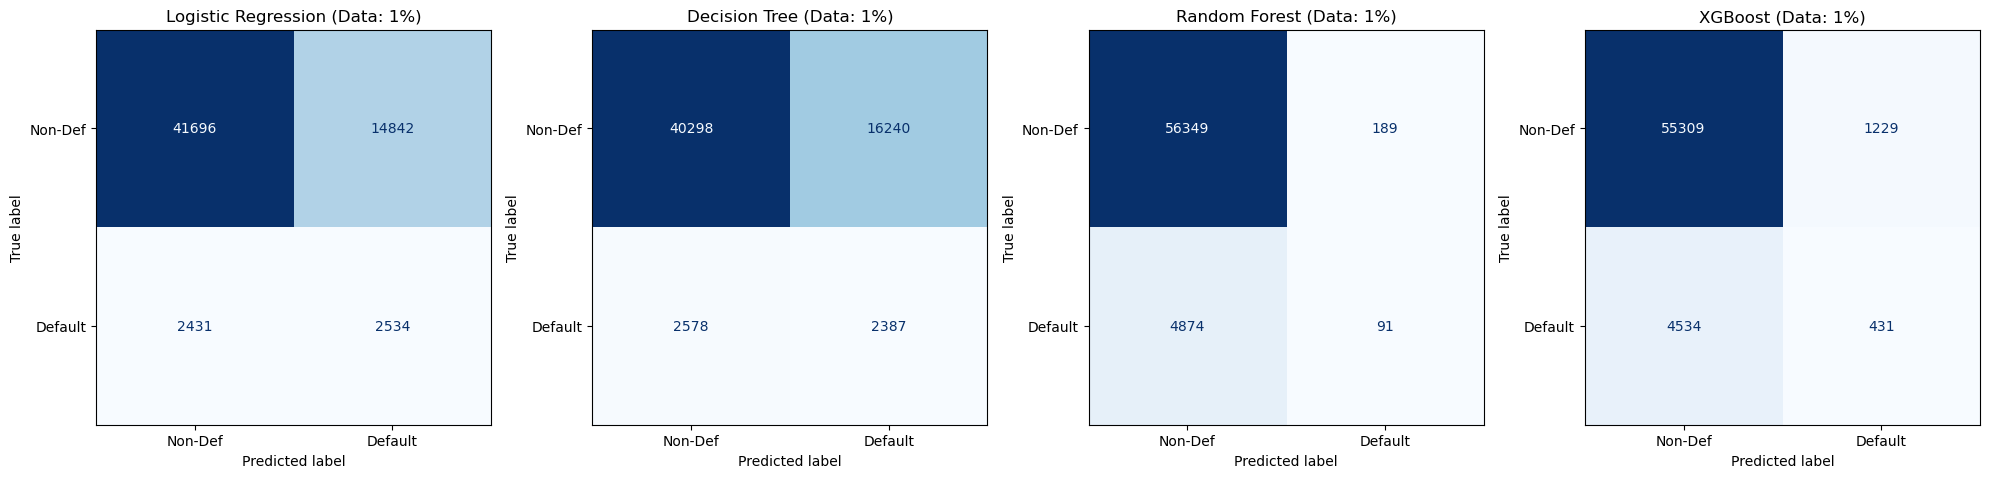

In [38]:
# ==========================================
# 4. 结果处理与可视化 (High Res)
# ==========================================
results_df = pd.DataFrame(results_list)
results_df.to_csv('experiment_results.csv', index=False)


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

target_frac_str = "1%"
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for i, model_name in enumerate(model_names):
    key = f"{model_name}_{target_frac_str}"
    
    if key in confusion_matrices:
        cm = confusion_matrices[key]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Def', 'Default'])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f"{model_name} (Data: {target_frac_str})")
    else:
        axes[i].set_title(f"{key} not found")

plt.tight_layout()
plt.show()

In [39]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# ==========================================
# 1. 定义模型配置 (Pipeline + 参数网格)
# ==========================================
# 计算 Scale Pos Weight (用于 XGBoost)
ratio = float(np.sum(y_train_full == 0)) / np.sum(y_train_full == 1)

# 我们把 Pipeline 和 参数网格 打包在一起
model_configs = {
    'Logistic Regression': (
        Pipeline([
            ('prep', linear_preprocessor),
            ('clf', LogisticRegression(class_weight='balanced', solver='saga', max_iter=2000, n_jobs=-1))
        ]),
        {
            'clf__C': [0.01, 0.1, 1, 10],           # 正则化强度
            'clf__penalty': ['l1', 'l2']            # Lasso vs Ridge
        }
    ),
    
    'Decision Tree': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ]),
        {
            'clf__max_depth': [5, 10, 15, 20],      # 树深
            'clf__min_samples_leaf': [10, 20, 50],  # 叶子节点最小样本
            'clf__criterion': ['gini', 'entropy']
        }
    ),

    'Random Forest': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200],        # 树的数量 (少一点省时间)
            'clf__max_depth': [10, 15, 20, None],   # 深度
            'clf__min_samples_leaf': [2, 5, 10]
        }
    ),
    
    'XGBoost': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', XGBClassifier(scale_pos_weight=ratio, tree_method='hist', eval_metric='aucpr', n_jobs=-1, random_state=42))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__max_depth': [3, 5, 7],
            'clf__subsample': [0.6, 0.8, 1.0],
            'clf__colsample_bytree': [0.6, 0.8, 1.0]
        }
    )
}

In [40]:
sample_fractions = [0.01, 0.02, 0.05, 0.1] 

# 这里我们定义 调参用的 CV (Inner Loop)
# 4折 CV 寻找最佳参数
tune_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

results_list = []
confusion_matrices = {} 

print(f"\n🚀 Starting Auto-Tuning Experiment...")
print(f"Fractions: {sample_fractions}")
print(f"Tuning Metric: PR-AUC (average_precision)")


🚀 Starting Auto-Tuning Experiment...
Fractions: [0.01, 0.02, 0.05, 0.1]
Tuning Metric: PR-AUC (average_precision)


In [42]:
frac = 0.01
X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full, 
        train_size=frac, 
        stratify=y_train_full, 
        random_state=42
    )
n_samples = X_sub.shape[0]
print(f"Subset Size: {n_samples}")

# --- B. 遍历模型进行调参和评估 ---
for name, (pipeline, param_grid) in model_configs.items():
    print(f"   > Tuning & Training {name}...", end=" ")
    start_time = time.time()
    
    try:
        # 1. Hyperparameter Tuning (Inner Loop)
        # 在当前子集上，寻找最佳参数
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=param_grid,
            n_iter=20, # 每个模型尝试 20 种组合 (为了时间考虑，10次够了)
            scoring='average_precision', # 你的首选指标
            cv=tune_cv,
            n_jobs=-1,
            random_state=42
        )
        
        search.fit(X_sub, y_sub)
        
        # 获取最佳模型和参数
        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_ # 这是调参时的最佳 CV PR-AUC
        
        # 2. Test Set Evaluation (Outer Evaluation)
        # 用找到的最佳模型，去考 Global Test
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        y_pred_class = best_model.predict(X_test)
        
        test_pr_auc = average_precision_score(y_test, y_pred_proba)
        test_roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # 3. 保存 Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_class)
        cm_key = f"{name}_{int(frac*100)}%"
        confusion_matrices[cm_key] = cm
        
        elapsed = time.time() - start_time
        print(f"Done ({elapsed:.1f}s)")
        print(f"     Best Params: {best_params}")
        print(f"     CV PR-AUC: {best_cv_score:.4f} | Test PR-AUC: {test_pr_auc:.4f} | Test ROC-AUC: {test_roc_auc:.4f}")
        
        # 4. 存结果
        results_list.append({
            'Fraction': frac,
            'Samples': n_samples,
            'Model': name,
            'Best_Params': str(best_params), # 转成字符串存，方便看
            'CV_PR_AUC_Best': best_cv_score, # 这是 tuning 得到的最佳分数
            'Test_PR_AUC': test_pr_auc,
            'Test_ROC_AUC': test_roc_auc,
            'Time_Sec': elapsed
        })
        
    except Exception as e:
        print(f"\n❌ Error in {name}: {e}")

Subset Size: 2460
   > Tuning & Training Logistic Regression... 

c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Done (126.6s)
     Best Params: {'clf__penalty': 'l1', 'clf__C': 0.01}
     CV PR-AUC: 0.2054 | Test PR-AUC: 0.2034 | Test ROC-AUC: 0.7210
   > Tuning & Training Decision Tree... Done (4.4s)
     Best Params: {'clf__min_samples_leaf': 50, 'clf__max_depth': 15, 'clf__criterion': 'entropy'}
     CV PR-AUC: 0.1564 | Test PR-AUC: 0.1220 | Test ROC-AUC: 0.6187
   > Tuning & Training Random Forest... Done (22.8s)
     Best Params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 2, 'clf__max_depth': 15}
     CV PR-AUC: 0.1982 | Test PR-AUC: 0.1675 | Test ROC-AUC: 0.6871
   > Tuning & Training XGBoost... Done (36.9s)
     Best Params: {'clf__subsample': 0.6, 'clf__n_estimators': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
     CV PR-AUC: 0.2263 | Test PR-AUC: 0.1968 | Test ROC-AUC: 0.7226


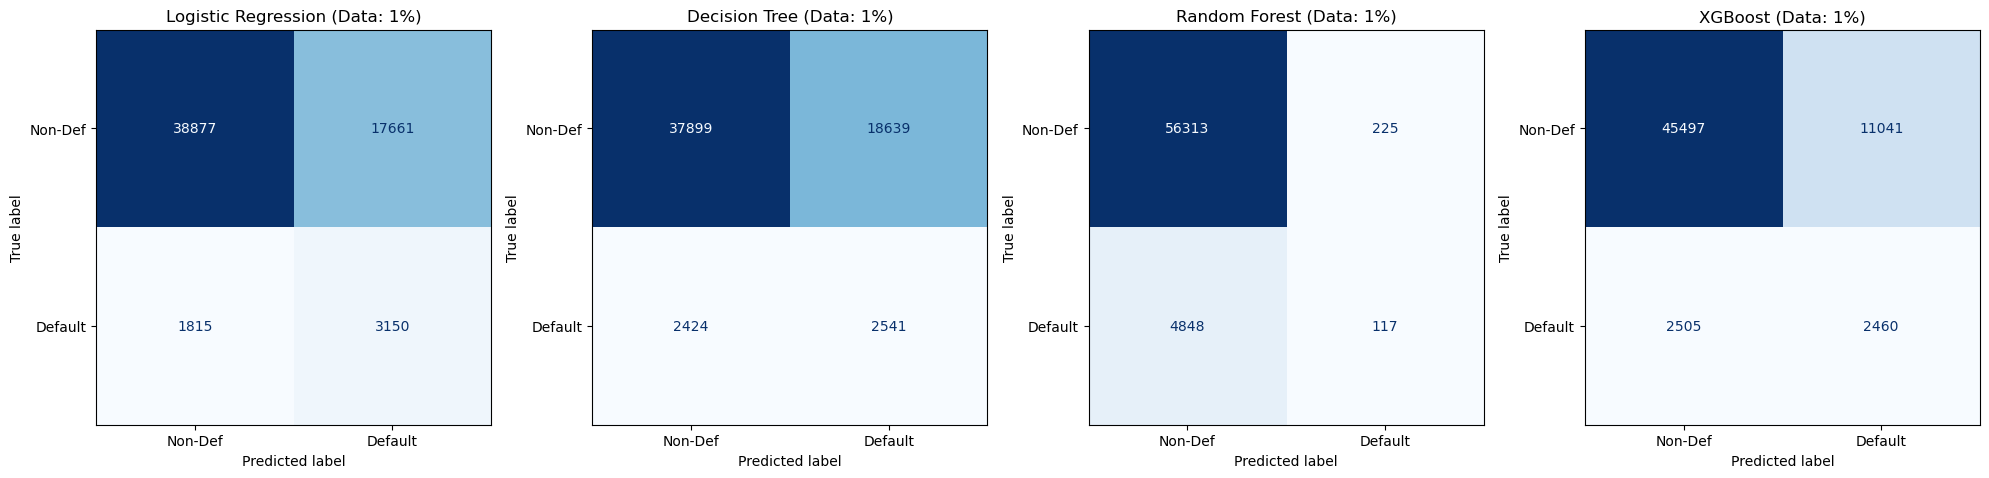

In [ ]:
# ==========================================
# 4. 结果处理与可视化 (High Res)
# ==========================================
results_df = pd.DataFrame(results_list)
results_df.to_csv('../results/experiment_results_tuned_01.csv', index=False)


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

target_frac_str = "1%"
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for i, model_name in enumerate(model_names):
    key = f"{model_name}_{target_frac_str}"
    
    if key in confusion_matrices:
        cm = confusion_matrices[key]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Def', 'Default'])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f"{model_name} (Data: {target_frac_str})")
    else:
        axes[i].set_title(f"{key} not found")

plt.tight_layout()
plt.show()

### loop

In [45]:
sample_fractions = [0.02, 0.05, 0.1] 

# 这里我们定义 调参用的 CV (Inner Loop)
# 4折 CV 寻找最佳参数
tune_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

results_list = []
confusion_matrices = {} 

print(f"\n🚀 Starting Auto-Tuning Experiment...")
print(f"Fractions: {sample_fractions}")
print(f"Tuning Metric: PR-AUC (average_precision)")


🚀 Starting Auto-Tuning Experiment...
Fractions: [0.02, 0.05, 0.1]
Tuning Metric: PR-AUC (average_precision)


In [46]:
for frac in sample_fractions:
    print(f"\n" + "="*60)
    print(f"Processing Data Fraction: {frac*100}%")
    print("="*60)
    
    # --- A. 抽样 ---
    X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full, 
        train_size=frac, 
        stratify=y_train_full, 
        random_state=42
    )
    n_samples = X_sub.shape[0]
    print(f"Subset Size: {n_samples}")
    
    # --- B. 遍历模型进行调参和评估 ---
    for name, (pipeline, param_grid) in model_configs.items():
        print(f"   > Tuning & Training {name}...", end=" ")
        start_time = time.time()
        
        try:
            # 1. Hyperparameter Tuning (Inner Loop)
            # 在当前子集上，寻找最佳参数
            search = RandomizedSearchCV(
                pipeline,
                param_distributions=param_grid,
                n_iter=10, # 每个模型尝试 10 种组合 (为了时间考虑，10次够了)
                scoring='average_precision', # 你的首选指标
                cv=tune_cv,
                n_jobs=-1,
                random_state=42
            )
            
            search.fit(X_sub, y_sub)
            
            # 获取最佳模型和参数
            best_model = search.best_estimator_
            best_params = search.best_params_
            best_cv_score = search.best_score_ # 这是调参时的最佳 CV PR-AUC
            
            # 2. Test Set Evaluation (Outer Evaluation)
            # 用找到的最佳模型，去考 Global Test
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]
            y_pred_class = best_model.predict(X_test)
            
            test_pr_auc = average_precision_score(y_test, y_pred_proba)
            test_roc_auc = roc_auc_score(y_test, y_pred_proba)
            
            # 3. 保存 Confusion Matrix
            cm = confusion_matrix(y_test, y_pred_class)
            cm_key = f"{name}_{int(frac*100)}%"
            confusion_matrices[cm_key] = cm
            
            elapsed = time.time() - start_time
            print(f"Done ({elapsed:.1f}s)")
            print(f"     Best Params: {best_params}")
            print(f"     CV PR-AUC: {best_cv_score:.4f} | Test PR-AUC: {test_pr_auc:.4f} | Test ROC-AUC: {test_roc_auc:.4f}")
            
            # 4. 存结果
            results_list.append({
                'Fraction': frac,
                'Samples': n_samples,
                'Model': name,
                'Best_Params': str(best_params), # 转成字符串存，方便看
                'CV_PR_AUC_Best': best_cv_score, # 这是 tuning 得到的最佳分数
                'Test_PR_AUC': test_pr_auc,
                'Test_ROC_AUC': test_roc_auc,
                'Time_Sec': elapsed
            })
            
        except Exception as e:
            print(f"\n❌ Error in {name}: {e}")


Processing Data Fraction: 2.0%
Subset Size: 4920
   > Tuning & Training Logistic Regression... 

c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done (359.7s)
     Best Params: {'clf__penalty': 'l1', 'clf__C': 0.01}
     CV PR-AUC: 0.1871 | Test PR-AUC: 0.1963 | Test ROC-AUC: 0.7206
   > Tuning & Training Decision Tree... Done (4.5s)
     Best Params: {'clf__min_samples_leaf': 20, 'clf__max_depth': 5, 'clf__criterion': 'entropy'}
     CV PR-AUC: 0.1317 | Test PR-AUC: 0.1386 | Test ROC-AUC: 0.6487
   > Tuning & Training Random Forest... Done (21.4s)
     Best Params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': None}
     CV PR-AUC: 0.1901 | Test PR-AUC: 0.1843 | Test ROC-AUC: 0.7025
   > Tuning & Training XGBoost... Done (31.7s)
     Best Params: {'clf__subsample': 0.6, 'clf__n_estimators': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
     CV PR-AUC: 0.2009 | Test PR-AUC: 0.2059 | Test ROC-AUC: 0.7285

Processing Data Fraction: 5.0%
Subset Size: 12300
   > Tuning & Training Logistic Regression... 

c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Done (658.1s)
     Best Params: {'clf__penalty': 'l2', 'clf__C': 0.01}
     CV PR-AUC: 0.2038 | Test PR-AUC: 0.2036 | Test ROC-AUC: 0.7305
   > Tuning & Training Decision Tree... Done (9.3s)
     Best Params: {'clf__min_samples_leaf': 20, 'clf__max_depth': 5, 'clf__criterion': 'entropy'}
     CV PR-AUC: 0.1463 | Test PR-AUC: 0.1607 | Test ROC-AUC: 0.6839
   > Tuning & Training Random Forest... Done (50.2s)
     Best Params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': None}
     CV PR-AUC: 0.1901 | Test PR-AUC: 0.1973 | Test ROC-AUC: 0.7203
   > Tuning & Training XGBoost... Done (47.6s)
     Best Params: {'clf__subsample': 0.6, 'clf__n_estimators': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
     CV PR-AUC: 0.2005 | Test PR-AUC: 0.2166 | Test ROC-AUC: 0.7361

Processing Data Fraction: 10.0%
Subset Size: 24600
   > Tuning & Training Logistic Regression... 

c:\Users\admin\anaconda3\envs\data1030\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Done (1440.2s)
     Best Params: {'clf__penalty': 'l2', 'clf__C': 0.01}
     CV PR-AUC: 0.2144 | Test PR-AUC: 0.2184 | Test ROC-AUC: 0.7438
   > Tuning & Training Decision Tree... Done (18.5s)
     Best Params: {'clf__min_samples_leaf': 20, 'clf__max_depth': 5, 'clf__criterion': 'gini'}
     CV PR-AUC: 0.1609 | Test PR-AUC: 0.1664 | Test ROC-AUC: 0.6926
   > Tuning & Training Random Forest... Done (102.9s)
     Best Params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': None}
     CV PR-AUC: 0.2066 | Test PR-AUC: 0.2070 | Test ROC-AUC: 0.7292
   > Tuning & Training XGBoost... Done (70.0s)
     Best Params: {'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
     CV PR-AUC: 0.2156 | Test PR-AUC: 0.2293 | Test ROC-AUC: 0.7440


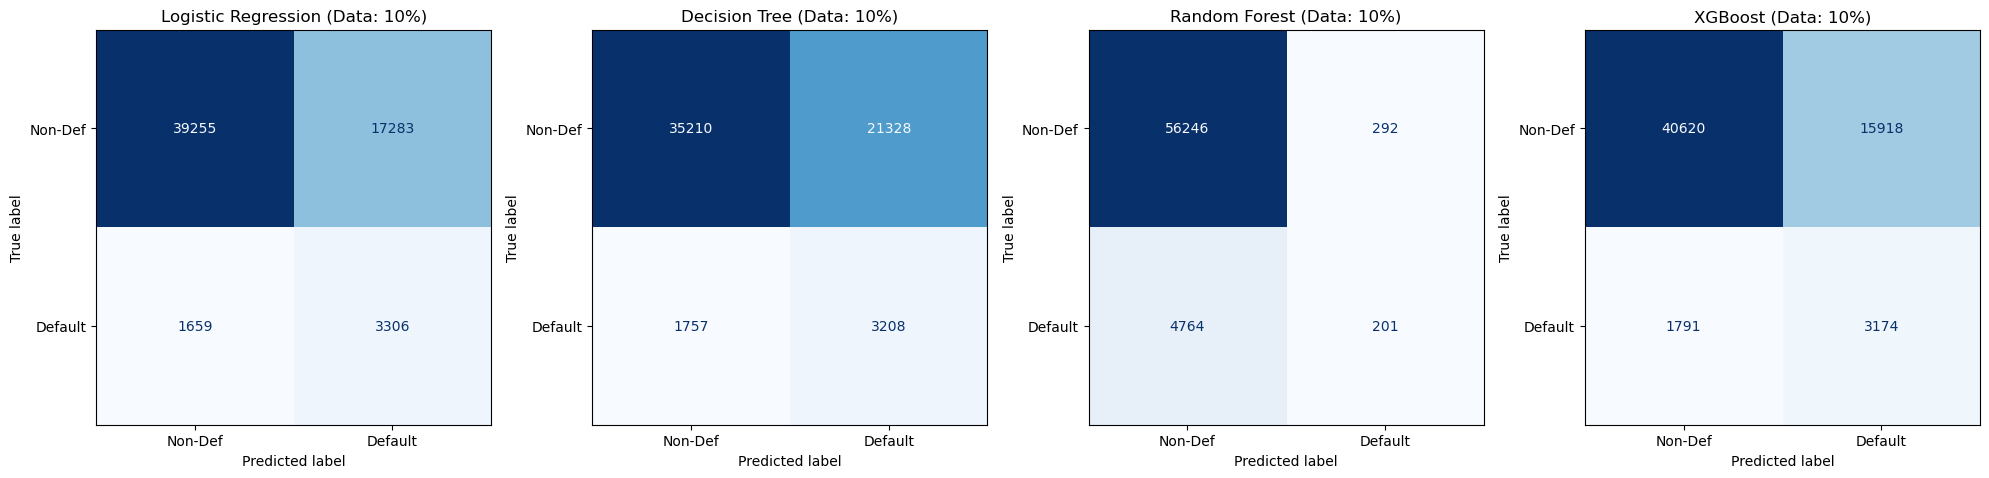

In [ ]:
# ==========================================
# 4. 结果处理与可视化 (High Res)
# ==========================================
results_df = pd.DataFrame(results_list)
results_df.to_csv('../results/experiment_results_tuned_10.csv', index=False)


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

target_frac_str = "10%"
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for i, model_name in enumerate(model_names):
    key = f"{model_name}_{target_frac_str}"
    
    if key in confusion_matrices:
        cm = confusion_matrices[key]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Def', 'Default'])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f"{model_name} (Data: {target_frac_str})")
    else:
        axes[i].set_title(f"{key} not found")

plt.tight_layout()
plt.show()

In [12]:
import time
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# ==========================================
# 1. 定义模型配置 (注释掉 Logistic Regression)
# ==========================================
ratio = float(np.sum(y_train_full == 0)) / np.sum(y_train_full == 1)

model_configs = {

    # 'Logistic Regression': (...),
    
    # ✅ 保留三个树模型
    'Decision Tree': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ]),
        {'clf__max_depth': [5, 10, 15, 20], 'clf__min_samples_leaf': [10, 20, 50], 'clf__criterion': ['gini', 'entropy']}
    ),
    'Random Forest': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
        ]),
        {'clf__n_estimators': [100, 200], 'clf__max_depth': [10, 15, 20, None], 'clf__min_samples_leaf': [2, 5, 10]}
    ),
    'XGBoost': (
        Pipeline([
            ('prep', tree_preprocessor),
            ('clf', XGBClassifier(scale_pos_weight=ratio, tree_method='hist', eval_metric='aucpr', n_jobs=-1, random_state=42))
        ]),
        {'clf__n_estimators': [100, 200, 300], 'clf__learning_rate': [0.01, 0.05, 0.1], 'clf__max_depth': [3, 5, 7], 'clf__subsample': [0.6, 0.8, 1.0], 'clf__colsample_bytree': [0.6, 0.8, 1.0]}
    )
}

# ==========================================
# 2. 实验设置 (大比例)
# ==========================================
# 直接从 20% 开始，一直跑到全量 (100%)
# 昨天跑过 10% 了，所以这里不用重复跑
sample_fractions = [0.2, 0.5, 0.8, 1.0] 

tune_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
results_list = []
confusion_matrices = {} 

# ⚠️ 关键：改个新名字，别覆盖昨天的！
csv_filename = 'experiment_results_trees_extended.csv'
pkl_filename = 'confusion_matrices_trees_extended.pkl'

print(f"\n🚀 Starting Extended Tree Experiment (20% -> 100%)...")
print(f"Results will be saved to '{csv_filename}'")

# ==========================================
# 3. 核心循环
# ==========================================
for frac in sample_fractions:
    print(f"\n" + "="*60)
    print(f"Processing Data Fraction: {frac*100}%")
    print("="*60)
    
    # A. 抽样
    if frac == 1.0:
        # 全量数据
        X_sub, y_sub = X_train_full, y_train_full
        n_samples = X_sub.shape[0]
    else:
        # 子集抽样
        X_sub, _, y_sub, _ = train_test_split(
            X_train_full, y_train_full, 
            train_size=frac, stratify=y_train_full, random_state=42
        )
        n_samples = X_sub.shape[0]
        
    print(f"Subset Size: {n_samples}")
    
    for name, (pipeline, param_grid) in model_configs.items():
        print(f"   > Tuning & Training {name}...", end=" ")
        start_time = time.time()
        
        try:
            # 1. Tuning
            search = RandomizedSearchCV(
                pipeline, param_distributions=param_grid,
                n_iter=10, scoring='average_precision', cv=tune_cv,
                n_jobs=-1, random_state=42
            )
            search.fit(X_sub, y_sub)
            
            # 2. Evaluation
            best_model = search.best_estimator_
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]
            y_pred_class = best_model.predict(X_test)
            
            test_pr_auc = average_precision_score(y_test, y_pred_proba)
            test_roc_auc = roc_auc_score(y_test, y_pred_proba)
            
            # 3. Save Confusion Matrix
            cm = confusion_matrix(y_test, y_pred_class)
            cm_key = f"{name}_{int(frac*100)}%"
            confusion_matrices[cm_key] = cm
            
            elapsed = time.time() - start_time
            print(f"Done ({elapsed:.1f}s) | PR-AUC: {test_pr_auc:.4f}")
            
            # 4. Save Results
            results_list.append({
                'Fraction': frac,
                'Samples': n_samples,
                'Model': name,
                'Best_Params': str(search.best_params_),
                'CV_PR_AUC_Best': search.best_score_,
                'Test_PR_AUC': test_pr_auc,
                'Test_ROC_AUC': test_roc_auc,
                'Time_Sec': elapsed
            })

            # Checkpoint Save
            pd.DataFrame(results_list).to_csv(csv_filename, index=False)
            with open(pkl_filename, 'wb') as f:
                pickle.dump(confusion_matrices, f)
            
        except Exception as e:
            print(f"\n❌ Error in {name}: {e}")
            pd.DataFrame(results_list).to_csv(csv_filename, index=False)

print("\n🎉 Extended Tree Experiment Completed!")


🚀 Starting Extended Tree Experiment (20% -> 100%)...
Results will be saved to 'experiment_results_trees_extended.csv'

Processing Data Fraction: 20.0%
Subset Size: 49201
   > Tuning & Training Decision Tree... Done (49.3s) | PR-AUC: 0.1715
   > Tuning & Training Random Forest... Done (253.5s) | PR-AUC: 0.2152
   > Tuning & Training XGBoost... Done (116.0s) | PR-AUC: 0.2404

Processing Data Fraction: 50.0%
Subset Size: 123004
   > Tuning & Training Decision Tree... Done (118.4s) | PR-AUC: 0.1804
   > Tuning & Training Random Forest... Done (724.5s) | PR-AUC: 0.2204
   > Tuning & Training XGBoost... Done (251.9s) | PR-AUC: 0.2445

Processing Data Fraction: 80.0%
Subset Size: 196806
   > Tuning & Training Decision Tree... Done (284.6s) | PR-AUC: 0.1792
   > Tuning & Training Random Forest... Done (1635.8s) | PR-AUC: 0.2226
   > Tuning & Training XGBoost... Done (566.1s) | PR-AUC: 0.2512

Processing Data Fraction: 100.0%
Subset Size: 246008
   > Tuning & Training Decision Tree... Done (36

KeyboardInterrupt: 